In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [2]:
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 130

In [58]:
df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")

df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
df.dropna(subset=["TotalCharges"], inplace=True)
df["SeniorCitizen"] = df["SeniorCitizen"].map({0: "No", 1: "Yes"})
df.drop(columns=["customerID"], inplace=True)

print("Shape:", df.shape)
print("Missing values:", df.isnull().sum().sum())
print("\nChurn counts:\n", df["Churn"].value_counts())

Shape: (7032, 20)
Missing values: 0

Churn counts:
 Churn
No     5163
Yes    1869
Name: count, dtype: int64



Overall churn rate:
 Churn
No     73.4
Yes    26.6
Name: proportion, dtype: float64


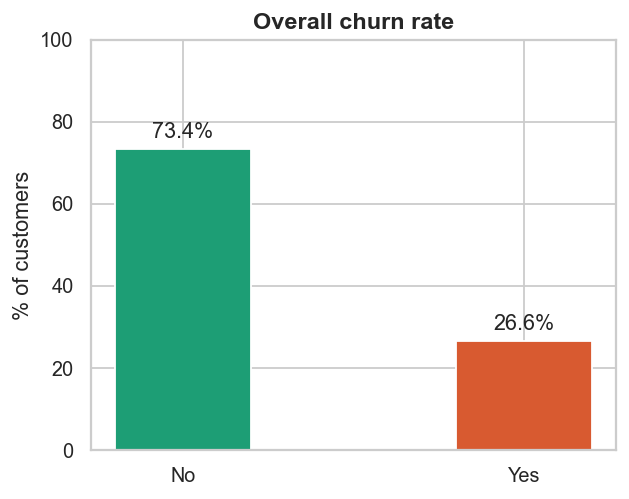

In [59]:
churn_rate = df["Churn"].value_counts(normalize=True).mul(100).round(1)
print("\nOverall churn rate:\n", churn_rate)

fig, ax = plt.subplots(figsize=(5, 4))
bars = ax.bar(churn_rate.index, churn_rate.values, color=["#1D9E75", "#D85A30"], width=0.4)
ax.bar_label(bars, fmt="%.1f%%", padding=4)
ax.set_title("Overall churn rate", fontsize=13, fontweight="bold")
ax.set_ylabel("% of customers")
ax.set_ylim(0, 100)
plt.tight_layout()
plt.show()


Contract distribution among churned customers:
 Contract
Month-to-month    88.6
One year           8.9
Two year           2.6
Name: proportion, dtype: float64


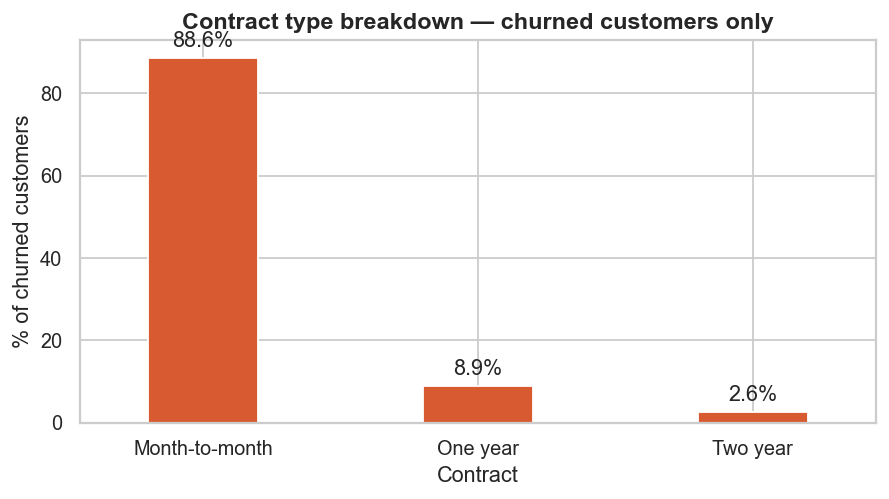

In [60]:
churned_only = df[df["Churn"] == "Yes"]
contract_dist = churned_only["Contract"].value_counts(normalize=True).mul(100).round(1)
print("\nContract distribution among churned customers:\n", contract_dist)

fig, ax = plt.subplots(figsize=(7, 4))
contract_dist.plot(kind="bar", ax=ax, color="#D85A30", width=0.4)
ax.bar_label(ax.containers[0], fmt="%.1f%%", padding=4)
ax.set_title("Contract type breakdown — churned customers only", fontsize=13, fontweight="bold")
ax.set_ylabel("% of churned customers")
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
plt.tight_layout()
plt.show()


Month-to-month tenure breakdown:
             Stayed  Churned  Total  Churn %
tenure_bin                                 
1-2            333      501    834     60.1
3-5            245      239    484     49.4
6-10           289      221    510     43.3
11-15          224      160    384     41.7
16-20          198      108    306     35.3
21-30          318      159    477     33.3
31-40          224      115    339     33.9
41-50          166       81    247     32.8
51-60          139       47    186     25.3
61-72           84       24    108     22.2


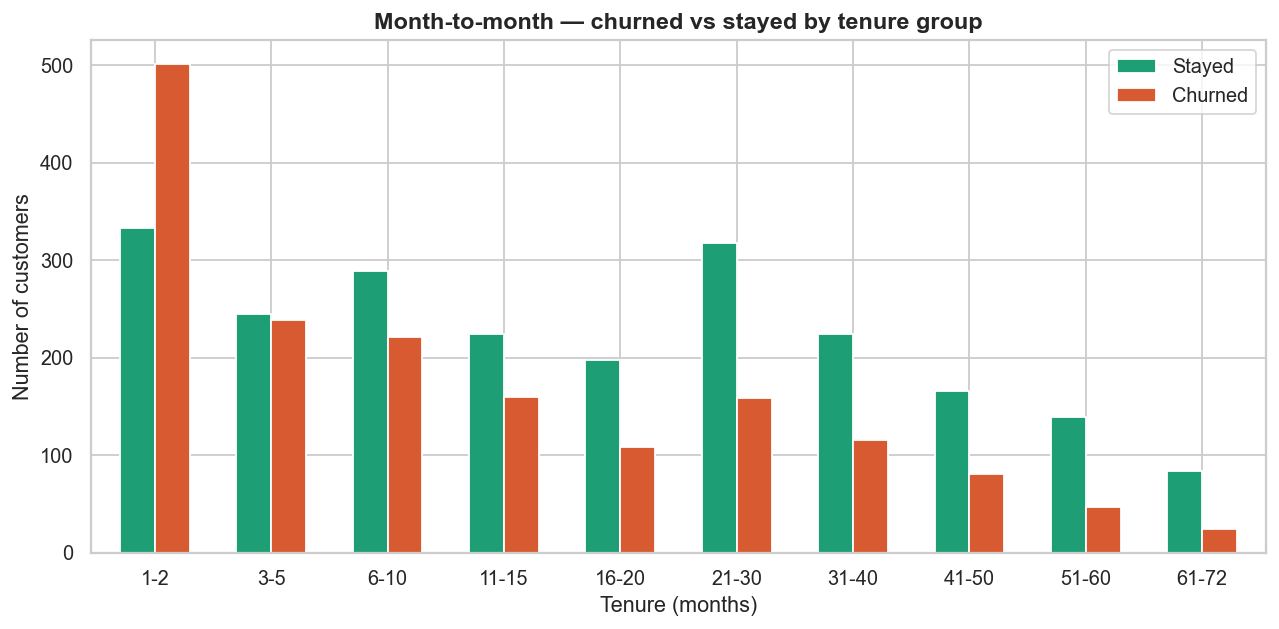

In [61]:
mtm = df[df["Contract"] == "Month-to-month"].copy()
bins  = [0, 2, 5, 10, 15, 20, 30, 40, 50, 60, 72]
labels = ["1-2", "3-5", "6-10", "11-15", "16-20", "21-30", "31-40", "41-50", "51-60", "61-72"]
mtm["tenure_bin"] = pd.cut(mtm["tenure"], bins=bins, labels=labels)

tenure_result = mtm.groupby("tenure_bin", observed=True)["Churn"].value_counts().unstack(fill_value=0)
tenure_result.columns = ["Stayed", "Churned"]
tenure_result["Total"] = tenure_result["Stayed"] + tenure_result["Churned"]
tenure_result["Churn %"] = (tenure_result["Churned"] / tenure_result["Total"] * 100).round(1)
print("\nMonth-to-month tenure breakdown:\n", tenure_result)

fig, ax = plt.subplots(figsize=(10, 5))
tenure_result[["Stayed", "Churned"]].plot(kind="bar", ax=ax, color=["#1D9E75", "#D85A30"], width=0.6)
ax.set_title("Month-to-month — churned vs stayed by tenure group", fontsize=13, fontweight="bold")
ax.set_xlabel("Tenure (months)")
ax.set_ylabel("Number of customers")
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
plt.tight_layout()
plt.show()

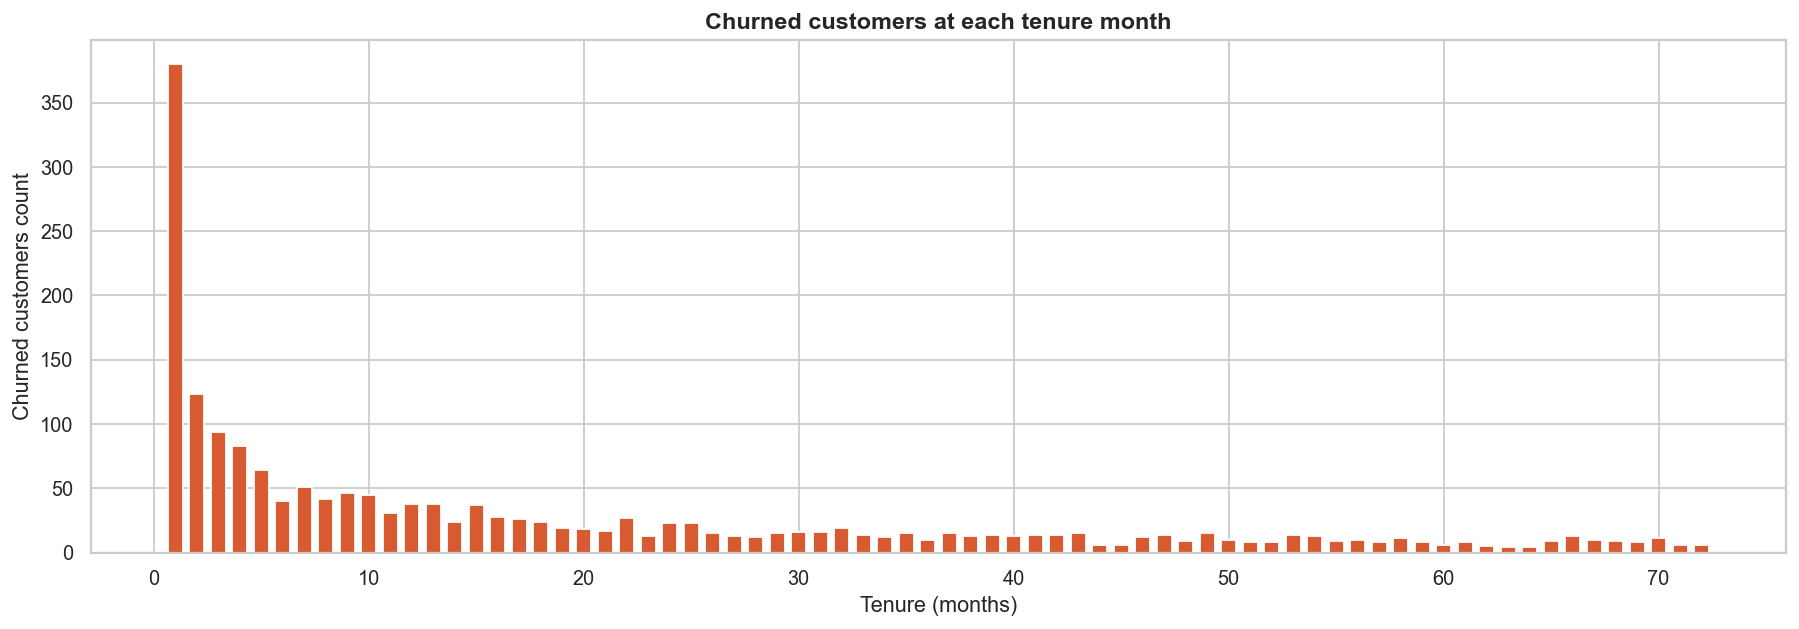

In [62]:
tenure_churn = df[df["Churn"] == "Yes"]["tenure"].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(14, 5))
ax.bar(tenure_churn.index, tenure_churn.values, color="#D85A30", width=0.7)
ax.set_title("Churned customers at each tenure month", fontsize=13, fontweight="bold")
ax.set_xlabel("Tenure (months)")
ax.set_ylabel("Churned customers count")
plt.tight_layout()
plt.show()

In [63]:
avg_charges = df.groupby("Contract")["MonthlyCharges"].mean().round(2)
print("\nAvg monthly charge by contract:\n", avg_charges)


Avg monthly charge by contract:
 Contract
Month-to-month    66.40
One year          65.08
Two year          60.87
Name: MonthlyCharges, dtype: float64



Internet service by churn (month-to-month):
 Churn  InternetService
No     Fiber optic         966
       DSL                 829
       No                  425
Yes    Fiber optic        1162
       DSL                 394
       No                   99
Name: count, dtype: int64

Avg monthly charge by internet service:
 InternetService
DSL            50.22
Fiber optic    87.02
No             20.41
Name: MonthlyCharges, dtype: float64

Churn rate by internet service (month-to-month):
 Churn              No   Yes
InternetService            
DSL              67.8  32.2
Fiber optic      45.4  54.6
No               81.1  18.9


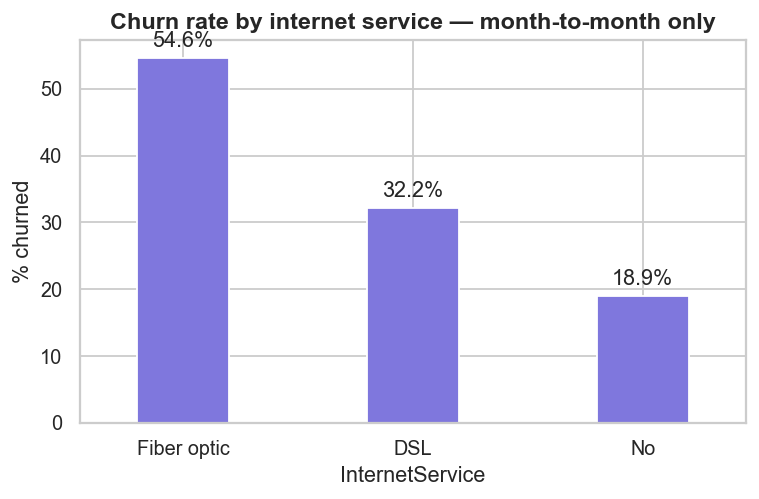

In [76]:
mtm_internet = df[df["Contract"] == "Month-to-month"]

internet_counts = mtm_internet.groupby("Churn")["InternetService"].value_counts()
print("\nInternet service by churn (month-to-month):\n", internet_counts)

internet_charges = mtm_internet.groupby("InternetService")["MonthlyCharges"].mean().round(2)
print("\nAvg monthly charge by internet service:\n", internet_charges)

internet_churn_rate = (
    mtm_internet.groupby("InternetService")["Churn"]
    .value_counts(normalize=True)
    .unstack()
    .mul(100)
    .round(1)
)
print("\nChurn rate by internet service (month-to-month):\n", internet_churn_rate)

fig, ax = plt.subplots(figsize=(6, 4))
internet_churn_rate["Yes"].sort_values(ascending=False).plot(kind="bar", ax=ax, color="#7F77DD", width=0.4)
ax.bar_label(ax.containers[0], fmt="%.1f%%", padding=4)
ax.set_title("Churn rate by internet service — month-to-month only", fontsize=13, fontweight="bold")
ax.set_ylabel("% churned")
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
plt.tight_layout()
plt.show()

In [65]:
month1_churned = df[(df["tenure"] == 1) & (df["Churn"] == "Yes")]

month1_summary = month1_churned.groupby("InternetService").agg(
    count=("MonthlyCharges", "count"),
    avg_monthly_charge=("MonthlyCharges", "mean"),
    tech_support_yes=("TechSupport", lambda x: (x == "Yes").sum()),
    tech_support_no=("TechSupport", lambda x: (x == "No").sum())
).round(2)
print("\nMonth 1 churners by internet service:\n", month1_summary)



Month 1 churners by internet service:
                  count  avg_monthly_charge  tech_support_yes  tech_support_no
InternetService                                                              
DSL                119               43.40                11              108
Fiber optic        203               77.76                 3              200
No                  58               20.08                 0                0


In [66]:
churned = df[df["Churn"] == "Yes"]
monthly_loss = churned["MonthlyCharges"].sum()

print(f"\n--- Revenue Impact ---")
print(f"Total churned customers:      {len(churned)}")
print(f"Monthly revenue lost:         ${monthly_loss:,.0f}")
print(f"Yearly revenue lost:          ${monthly_loss * 12:,.0f}")

fiber_month1_no_support = month1_churned[
    (month1_churned["InternetService"] == "Fiber optic") &
    (month1_churned["TechSupport"] == "No")
]
potential_save = fiber_month1_no_support["MonthlyCharges"].sum()
print(f"\nFiber optic month-1 churners with no tech support: {len(fiber_month1_no_support)}")
print(f"Potential monthly revenue saved if retained:       ${potential_save:,.0f}")
print(f"Potential yearly revenue saved:                    ${potential_save * 12:,.0f}")


--- Revenue Impact ---
Total churned customers:      1869
Monthly revenue lost:         $139,131
Yearly revenue lost:          $1,669,570

Fiber optic month-1 churners with no tech support: 200
Potential monthly revenue saved if retained:       $15,533
Potential yearly revenue saved:                    $186,396
